In [8]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

In [11]:
df = pd.read_csv("India_AQI_Daily_2025.csv")
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10220 entries, 0 to 10219
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          10220 non-null  str    
 1   State         10220 non-null  str    
 2   AQI           10220 non-null  int64  
 3   AQI_Category  10220 non-null  str    
 4   PM2.5         10220 non-null  float64
 5   PM10          10220 non-null  float64
 6   NO2           10220 non-null  float64
 7   SO2           10220 non-null  float64
 8   CO            10220 non-null  float64
 9   O3            10220 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 798.6 KB


,AQI,PM2.5,PM10,NO2,SO2,CO,O3
count,10220.000000,10220.000000,10220.000000,10220.00000,10220.000000,10220.000000,10220.000000
mean,141.276908,59.304843,101.837270,22.57135,7.061996,0.785080,58.714384
std,38.944068,16.655317,28.577545,6.44727,2.031848,0.223275,4.279522
min,40.000000,11.600000,21.200000,3.70000,1.000000,0.140000,46.200000
25%,114.000000,47.500000,82.100000,18.10000,5.600000,0.630000,55.700000
50%,141.000000,59.300000,101.900000,22.60000,7.100000,0.790000,58.700000
75%,169.000000,71.000000,122.000000,27.10000,8.500000,0.940000,61.800000
max,240.000000,104.800000,180.900000,40.40000,12.700000,1.410000,71.400000


In [12]:
df.isnull().sum()

Date            0
State           0
AQI             0
AQI_Category    0
PM2.5           0
PM10            0
NO2             0
SO2             0
CO              0
O3              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10220 entries, 0 to 10219
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          10220 non-null  datetime64[us]
 1   State         10220 non-null  str           
 2   AQI           10220 non-null  int64         
 3   AQI_Category  10220 non-null  str           
 4   PM2.5         10220 non-null  float64       
 5   PM10          10220 non-null  float64       
 6   NO2           10220 non-null  float64       
 7   SO2           10220 non-null  float64       
 8   CO            10220 non-null  float64       
 9   O3            10220 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 798.6 KB


In [16]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

df["Day"] = df["Date"].dt.day
df.head()

,Date,State,AQI,AQI_Category,PM2.5,PM10,NO2,SO2,CO,O3,Year,Month,Day
0,2025-01-01,Andhra Pradesh,201,Poor,79.4,151.5,34.8,10.1,1.09,52.7,2025,January,1
1,2025-01-01,Arunachal Pradesh,124,Moderate,46.9,87.3,17.1,6.7,0.79,56.1,2025,January,1
2,2025-01-01,Assam,176,Moderate,75.3,127.8,25.6,9.6,1.03,51.2,2025,January,1
3,2025-01-01,Bihar,151,Moderate,69.2,117.5,25.0,8.4,0.81,62.0,2025,January,1
4,2025-01-01,Chhattisgarh,176,Moderate,69.2,120.7,25.9,9.0,0.90,52.3,2025,January,1


In [17]:
df.to_csv("Clean_AQI_2025.csv", index=False)

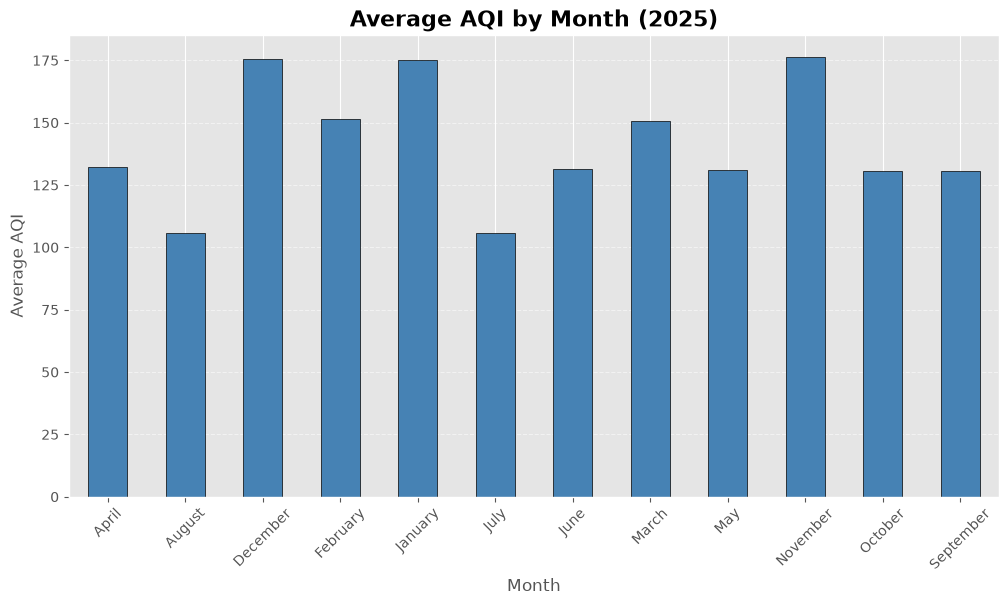

In [20]:
import matplotlib.pyplot as plt

monthly_avg = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(12,6))
monthly_avg.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Average AQI by Month (2025)", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

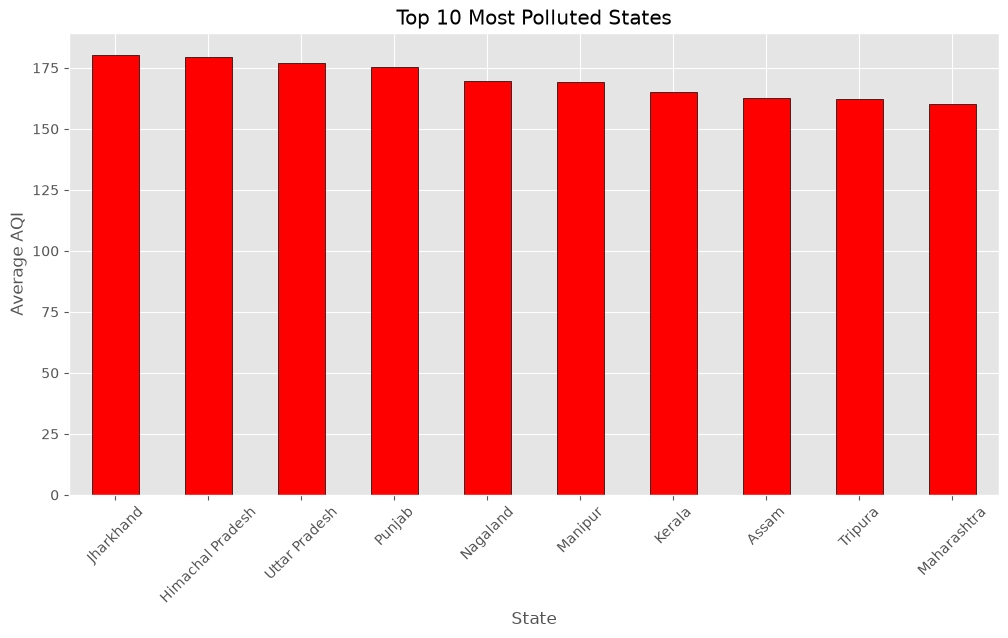

In [21]:
top_states = df.groupby("State")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind="bar", color="red", edgecolor="black")

plt.title("Top 10 Most Polluted States")
plt.xlabel("State")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)

plt.show()

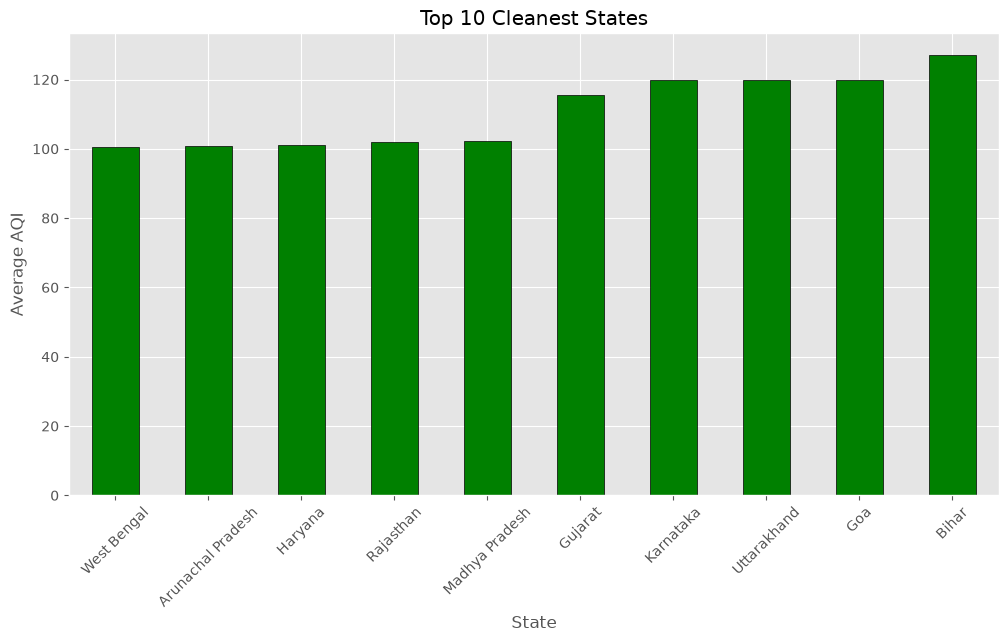

In [22]:
clean_states = df.groupby("State")["AQI"].mean().sort_values().head(10)

plt.figure(figsize=(12,6))
clean_states.plot(kind="bar", color="green", edgecolor="black")

plt.title("Top 10 Cleanest States")
plt.xlabel("State")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)

plt.show()

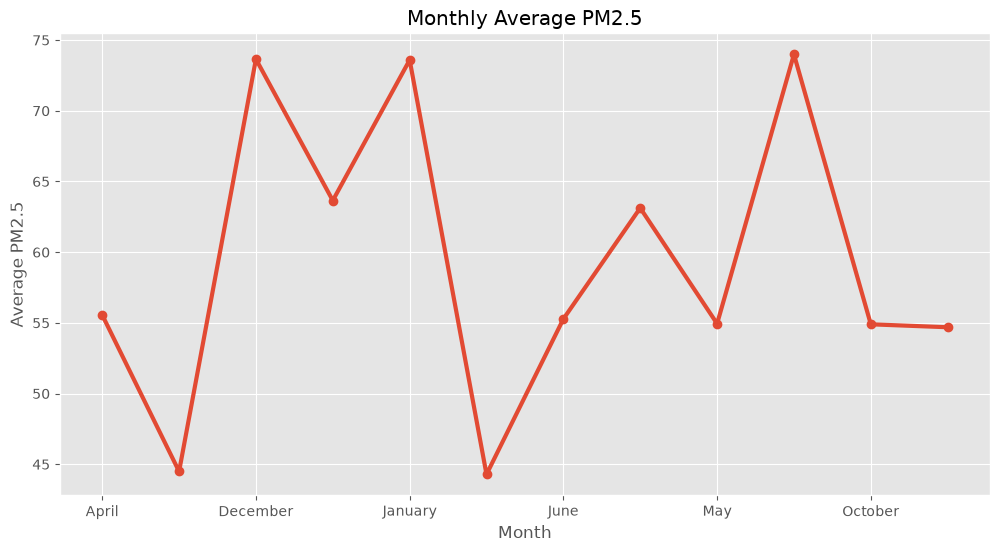

In [23]:
pm = df.groupby("Month")["PM2.5"].mean()

plt.figure(figsize=(12,6))
pm.plot(marker="o", linewidth=3)

plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")

plt.grid(True)

plt.show()

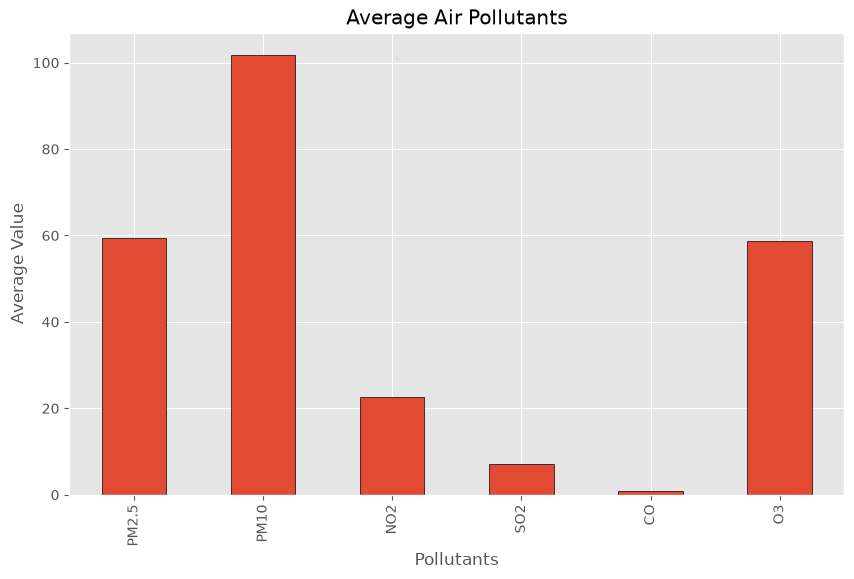

In [24]:
avg = df[["PM2.5","PM10","NO2","SO2","CO","O3"]].mean()

plt.figure(figsize=(10,6))
avg.plot(kind="bar", edgecolor="black")

plt.title("Average Air Pollutants")
plt.xlabel("Pollutants")
plt.ylabel("Average Value")

plt.show()

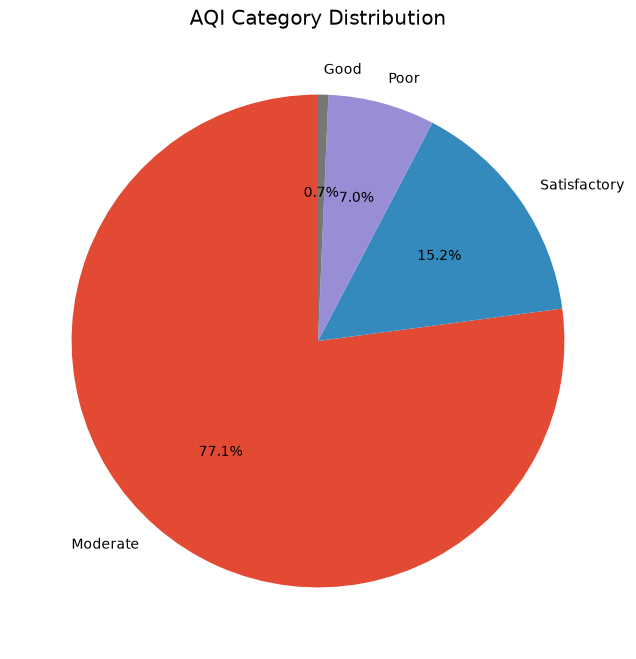

In [25]:
category = df["AQI_Category"].value_counts()

plt.figure(figsize=(8,8))
category.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("AQI Category Distribution")

plt.show()

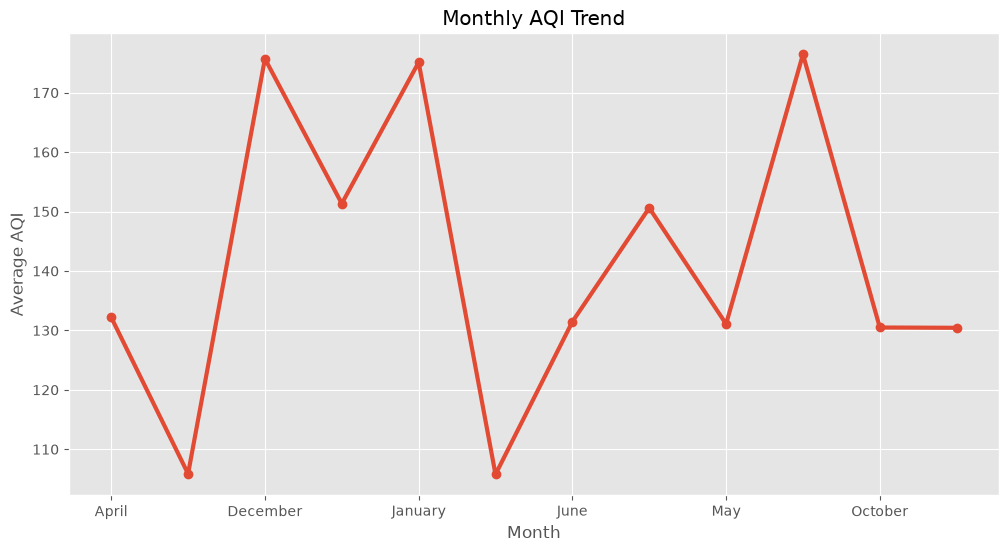

In [26]:
trend = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(12,6))
trend.plot(marker="o", linewidth=3)

plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

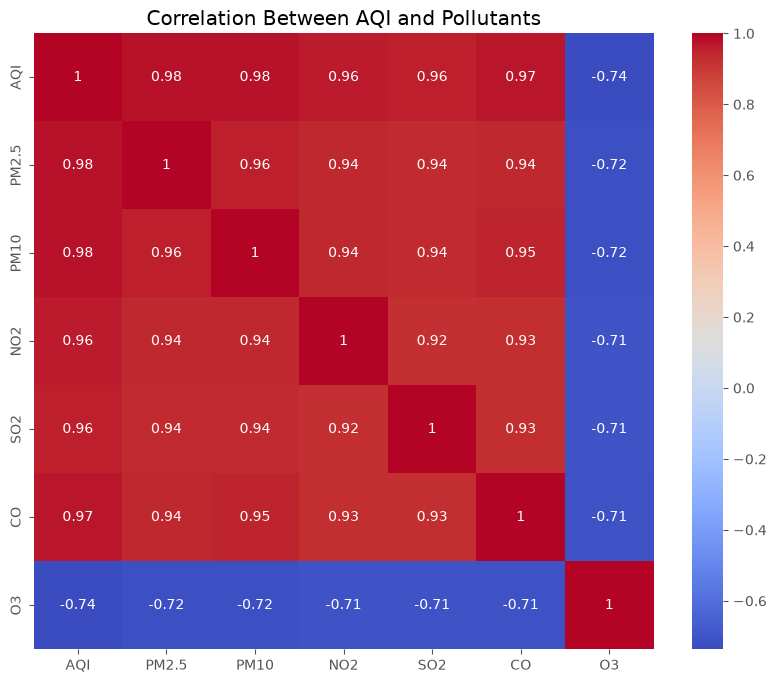

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[["AQI","PM2.5","PM10","NO2","SO2","CO","O3"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between AQI and Pollutants")

plt.show()